# gRNA LFC along sequence  
showing the LFC at nucleotide

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import ScalarFormatter
import numpy as np
import seaborn as sns
from Bio import SeqIO
import warnings
warnings.filterwarnings("ignore")
import scipy
import scipy.stats as stats
from matplotlib.colors import Normalize
import matplotlib.lines as mlines
import re
import pyranges as pr
from scipy import stats
from statsmodels.stats.multitest import multipletests

from matplotlib import font_manager
import matplotlib as mpl

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [21]:
id_prefix_list = [
	"MYC_GFP_"
]

# slight relaxing the boundary
dict_zoom = {
	'5end': {'start': 127733950, 'end': 127736625},
	'5utr_1': {'start': 127735984, 'end': 127736723},	
	'5utr_2': {'start': 127738148, 'end': 127738362},	
	'intron_1': {'start': 127736524, 'end': 127738347},
	'intron_2': {'start': 127738920, 'end': 127740495},
	'3utr':{'start': 127740859, 'end': 127741534}
}

In [22]:
# remove negative controls that can be mapped to the genome (with bowtie)
mapped_ctrl_path = "/media/scratch/fy2306/projects/base_editing/data/bowtie/all/all_sgrna_seqs.bowtie_hg38.mismatch1.processed.tsv"
mapped_ctrl_df = pd.read_csv(mapped_ctrl_path, sep="\t")
mapped_ctrl_df = mapped_ctrl_df[
    mapped_ctrl_df['id'].str.startswith(('Random', 'Non-targeting-controls', 'AAVS1'))
    & ~(mapped_ctrl_df['id'].str.startswith('AAVS1') & (mapped_ctrl_df['Alignments_NM0'] == 1) & (mapped_ctrl_df['Alignments_NM1'] == 0))
]
mapped_ctrl_list = mapped_ctrl_df["id"].tolist()
print(len(mapped_ctrl_list))
all_ctrl = [
    record.id for record in SeqIO.parse("/media/scratch/fy2306/projects/base_editing/data/bowtie/negative_controls/input/negative_controls.fa", "fasta")
    ]
clean_ctrl_list = list(set(all_ctrl)-set(mapped_ctrl_list))
print(len(clean_ctrl_list))
print(len(all_ctrl))

91
474
565


In [23]:
# randomly group nc sgrnas
def group_and_aggregate(df, group_size, random_state=None):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    num_groups = len(df_shuffled) // group_size
    df_trimmed = df_shuffled.iloc[:num_groups * group_size]
    
    grouped = np.array_split(df_trimmed, num_groups)
    
    aggregated = []
    for group in grouped:
        sgrna_concat = ','.join(group['sgrna'].astype(str))
        avg_lfc = group['per time unit LFC'].mean()
        aggregated.append({
            'sgrna': sgrna_concat,
            'per time unit LFC': avg_lfc
        })
    
    return pd.DataFrame(aggregated)

In [24]:
def scatter_LFC_nucleotide(df, ax, edited_pos_chr_col, ymin, ymax, gene_start, gene_end, xticks_label = None, yticks_label = None, xticks = False, cds = False):

	# Sort by genomic position
	df = df.sort_values(by=edited_pos_chr_col).reset_index(drop=True)
	df["neg|lfc"] = df["neg|lfc"].clip(lower=ymin, upper=ymax)

	# add exon shades
	if cds == True:
		exons = [(127736084, 127736623), (127738248, 127739019), (127740396, 127741434)]
		for x1, x2 in exons:
			# ax.axvline(x=x1, color='#107F80', linestyle='--')
			# ax.axvline(x=x2, color='#107F80', linestyle='--')
			ax.axvspan(x1, x2, color='#107F80', alpha=0.07)
		cdss = [(127738263, 127739019), (127740396, 127740958)]
		for x1, x2 in cdss:
			ax.axvspan(x1, x2, color='#107F80', alpha=0.1)

	# plot all the points
	ax.scatter(df[edited_pos_chr_col], df["neg|lfc"], alpha=0.3, s=0.6, color='grey', label="_nolegend_")

	# repeat region
	# ax.axvline(127739964, linestyle="--", color='black', linewidth=0.5)
	# ax.axvline(127740251, linestyle="--", color='black', linewidth=0.5)
	# ax.axvspan(127739964, 127740251, color='grey', alpha=0.1)
	# overlap PS0723:7905+
	highlight_pos = 127741049
	highlight_row = df[df[edited_pos_chr_col] == highlight_pos]

	# # Plot PS0723
	# ax.scatter(
	# 	highlight_row[edited_pos_chr_col],
	# 	highlight_row["neg|lfc"],
	# 	color='#40007F',
	# 	s=5,
	# 	label=f"PS0723",
	# 	zorder=5
	# )

	# repeats: blue
	df_repeats = df[df['indel_repeats'] == True]

	ax.scatter(
		df_repeats[edited_pos_chr_col],
		df_repeats["neg|lfc"],
		alpha=0.3,
		s=0.6,
		color='#40007F',
		label='Repeats'
	)

	# color by fdr 
	df_sig = df[(df['fdr'] < 0.05) & (df['indel_repeats'] == False) & (df['direction'] == True)]

	ax.scatter(
		df_sig[edited_pos_chr_col],
		df_sig["neg|lfc"],
		alpha=0.9,
		s=5,              # slightly larger to make them stand out
		color='#FF0066',
		label='Significant bp'
	)

	# lollipop
	ax.vlines(
		x=df_sig[edited_pos_chr_col],
		ymin=0,
		ymax=df_sig["neg|lfc"],
		colors='#FF0066',
		alpha=0.2,
		linewidth=0.15
	)

	ax.axhline(0, linestyle="--", color='black', linewidth=0.5)

	ax.set_ylabel('base pair phenotype score', fontsize=16)
	ax.set_xlim(gene_start, gene_end)
	ax.set_ylim(ymin, ymax)
	print(ymin, ymax)
	ax.set_xlabel('')
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)
	handles = [
		# mlines.Line2D([], [], color='grey', marker='o', linestyle='None', markersize=2, label='All bp'),
		mlines.Line2D([], [], color='#40007F', marker='o', linestyle='None', markersize=2, label='Repeats'),
		mlines.Line2D([], [], color='#FF0066', marker='o', linestyle='None', markersize=2, label='Significant bp')
	]
	ax.legend(handles=handles, loc="lower right", frameon=True, fontsize=13, markerscale=2.5, ncol=2)
	if yticks_label is not None:
		ax.set_yticks(yticks_label)
	else:
		ax.set_yticks([-0.15, -0.075, 0.0, 0.075])
	ax.ticklabel_format(style='plain', axis='y')
	if xticks == False:
		ax.set_xticks([])
		ax.set_xticklabels([])
	else:
		if xticks_label is not None:
			ax.set_xticks(xticks_label)
		else:
			ax.set_xticks([127735000, 127737500, 127740000, 127742500])
		ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable offset and scientific notation
		ax.ticklabel_format(style='plain', axis='x')
		ax.tick_params(axis='both', which='both', direction='in', length=6, width=1, labelsize=13)
		ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

In [25]:
def scatter_LFC_nucleotide_simple(df, ax, edited_pos_chr_col, ymin, ymax, gene_start, gene_end, xticks_label = None, yticks_label = None, xticks = False, cds = False):

	# Sort by genomic position
	df = df.sort_values(by=edited_pos_chr_col).reset_index(drop=True)
	df["neg|lfc"] = df["neg|lfc"].clip(lower=ymin, upper=ymax)

	# plot all the points
	ax.scatter(df[edited_pos_chr_col], df["neg|lfc"], alpha=0.3, s=0.6, color='grey', label="_nolegend_")
	
	# repeats: blue
	df_repeats = df[df['indel_repeats'] == True]

	ax.scatter(
		df_repeats[edited_pos_chr_col],
		df_repeats["neg|lfc"],
		alpha=0.3,
		s=0.6,
		color='#40007F',
		label='Repeats'
	)

	ax.axhline(0, linestyle="--", color='black', linewidth=0.5)

	ax.set_ylabel('base pair phenotype score', fontsize=16)
	ax.set_xlim(gene_start, gene_end)
	ax.set_ylim(ymin, ymax)
	print(ymin, ymax)
	ax.set_xlabel('')
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)
	if yticks_label is not None:
		ax.set_yticks(yticks_label)
	else:
		ax.set_yticks([-0.15, -0.075, 0.0, 0.075])
	ax.ticklabel_format(style='plain', axis='y')
	if xticks == False:
		ax.set_xticks([])
		ax.set_xticklabels([])
	else:
		if xticks_label is not None:
			ax.set_xticks(xticks_label)
		else:
			ax.set_xticks([127735000, 127737500, 127740000, 127742500])
		ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable offset and scientific notation
		ax.ticklabel_format(style='plain', axis='x')
		ax.tick_params(axis='both', which='both', direction='in', length=6, width=1, labelsize=13)
		ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

In [26]:
def gene_anno(ax_gene, gene_annotation, gene_start, gene_end, ylabel):

	gene = gene_annotation['gene']
	exon = gene_annotation['exon']
	cds = gene_annotation['cds']

	# straight line for entire gene
	ax_gene.hlines(0, gene_start, gene_end, color='grey', linewidth=1)	# head & tail
	ax_gene.hlines(0, gene['start'], gene['end'], color='m', linewidth=1.5)

	# arrows for the strand
	arrow_spacing = (gene_end - gene_start) // 40
	arrow_size = 15
	arrow_color = 'purple'

	if gene['strand'] == '+':
		arrow_positions = range(gene['start']+100, gene['end']-100, arrow_spacing)
		ax_gene.scatter(arrow_positions, [0] * len(arrow_positions), marker='>', s=arrow_size,
						edgecolor=arrow_color, facecolor=arrow_color, linewidth=0.8)
	elif gene['strand'] == '-':
		arrow_positions = range(gene['end']-100, gene['start']+100, -arrow_spacing)
		ax_gene.scatter(arrow_positions, [0] * len(arrow_positions), marker='<', s=arrow_size,
						edgecolor=arrow_color, facecolor=arrow_color, linewidth=0.8)

	# exons (thin boxes)
	for region in exon:
		ax_gene.add_patch(patches.Rectangle((region['start'], -0.1), region['end'] - region['start'], 0.18, 
											color='m', alpha=1))

	# CDSs (thick boxes)
	for region in cds:
		ax_gene.add_patch(patches.Rectangle((region['start'], -0.3), region['end'] - region['start'], 0.6, 
											color='m', alpha=1))
	

	# Adjust gene plot
	ax_gene.set_ylim(-0.2, 0.2)
	ax_gene.spines['top'].set_visible(False)
	ax_gene.spines['bottom'].set_visible(False)
	ax_gene.spines['right'].set_visible(False)
	ax_gene.spines['left'].set_visible(False)
	ax_gene.spines.values().__iter__()
	ax_gene.set_xticks([])
	ax_gene.set_xticklabels([])
	ax_gene.set_xlabel('')
	ax_gene.set_yticks([])
	ax_gene.set_ylabel(ylabel, rotation=0)

In [27]:
def scatter_LFC_nucleotide_merge(
		gene, 
		date,
		test_name,
		nc_test_name,
		merge_method_nucleotide, 
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, per_time_unit=True, title=None, plot_start=None, plot_end=None, figsize=None):
	
	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "nucleotide_pos"
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)

	# check
	count = df[edited_pos_chr_col].value_counts()
	num_duplicates = (count > 1).sum()
	print(f"{num_duplicates} values occur more than once.")

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]
	treatment_fdr_columns = [f"{treatment}_vs_{baseline}|neg|fdr" for treatment in treatments]
	treatment_fdr_goodsgrna_columns = [f"{treatment}_vs_{baseline}|neg|goodsgrna" for treatment in treatments]
	treatment_fdr_pos_columns = [f"{treatment}_vs_{baseline}|pos|fdr" for treatment in treatments]
	treatment_fdr_pos_goodsgrna_columns = [f"{treatment}_vs_{baseline}|pos|goodsgrna" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			print(col, day)
			df[col] = df[col] / (day + 0) # per time unit

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)
	
	# check on directionality and number of goodsgrna
	for fdr_col, goodsgrna_col in zip(treatment_fdr_columns, treatment_fdr_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["neg|fdr"] = df[treatment_fdr_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	df["direction"] = df[treatment_lfc_columns].apply(lambda row: (row.gt(0).all() or row.lt(0).all()), axis=1)
	
	# check on fdr
	# why fdr < 0.05 with very low lfc?
	# 2 of the 4 replicates have neg|lfc > 0
	df_suspicious = df[(df["neg|fdr"] < 0.05) & (df["neg|lfc"] > -0.025)]
	df_suspicious = df_suspicious.sort_values(by=edited_pos_chr_col).reset_index(drop=True)
	print(df_suspicious[[c for c in df_suspicious.columns if "neg|lfc" in c]])
	print(df_suspicious[[c for c in df_suspicious.columns if "neg|fdr" in c]])
	# pos|fdr: only MYC_GFP_127740986 (short 3'utr) has 2 out of 4 reps with pos|fdr < 0.05
	# MYC_GFP_127740986 is not showing the same directional trend in all 4 samples, even when the negative control subtraction was done at this step.
	for fdr_col, goodsgrna_col in zip(treatment_fdr_pos_columns, treatment_fdr_pos_goodsgrna_columns):
		df.loc[df[goodsgrna_col] < 2, fdr_col] = 1
	df["pos|fdr"] = df[treatment_fdr_pos_columns].apply(lambda row: sorted(row)[1], axis=1)	# second-lowest fdr
	print(df[df["pos|fdr"] < 0.05])
	df["fdr"] = df[["neg|fdr", "pos|fdr"]].min(axis=1)

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats"] = False
	df.loc[overlap_indices, "indel_repeats"] = True

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0)

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	print(len(df_nc))
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value
	# save as bedgraph for viz
	df_bedgraph = df[['Chromosome', 'Start', 'End', 'neg|lfc']].copy()
	df_bedgraph.to_csv('/media/scratch/fy2306/projects/base_editing/results/20250416/nucleotide_negLFC_timeunit_mean_4.bedGraph', sep='\t', header=False, index=False)
	# save as table
	df[['Chromosome', edited_pos_chr_col, 'neg|lfc', 'fdr', 'direction', 'indel_repeats']].sort_values(by=edited_pos_chr_col).to_csv('/media/scratch/fy2306/projects/base_editing/results/20250416/nucleotide_negLFC_timeunit_mean_4.tsv', sep='\t', index=False)

	if gene == "MYC":
		chromosome = "8"
		gene_start = int(df[edited_pos_chr_col].min()) - 100
		gene_end = int(df[edited_pos_chr_col].max()) + 100
		print(f"Actual gene boundary: {df[edited_pos_chr_col].min()}  {df[edited_pos_chr_col].max()}")
		print(gene_start, gene_end)
		strand = "+"
		# Current Ensembl/Refseq annotations do not seem to reach an agreement on c-Myc.  
		# According to RNA-Seq in D11
		# ENST00000377970.6
		gene_annotation_ENST00000377970 = {
			'gene': {'start': 127736084, 'end': 127741434, 'strand': '+'},
			'exon': [{'start': 127736084, 'end': 127736623}, {'start': 127738248, 'end': 127739019}, {'start': 127740396, 'end': 127741434}],
			'cds': [{'start': 127738263, 'end': 127739019}, {'start': 127740396, 'end': 127740958}]
			}


	# plot
	if figsize is None:
		figsize = (17, 2.5)
	fig, (ax_smooth) = plt.subplots(1, 1, sharex=True, figsize=figsize, gridspec_kw={'height_ratios': [1], 'hspace': 0.05})

	# ax_smooth: 
	scatter_LFC_nucleotide(
		df = df,
		ax = ax_smooth, 
		edited_pos_chr_col = edited_pos_chr_col, 
		ymin = -0.175, 
		ymax = 0.085, 
		gene_start = gene_start,
		gene_end = gene_end,
		xticks = True,
		cds = True
	)
	if plot_start is not None and plot_end is not None:
		ax_smooth.set_xlim(plot_start, plot_end)

	# ax_ENST00000377970: myc2 ENST00000377970 anno
	# add in genome browser
	# gene_anno(
	# 	ax_gene = ax_ENST00000377970,
	# 	gene_annotation = gene_annotation_ENST00000377970,
	# 	gene_start = gene_start,
	# 	gene_end = gene_end,
	# 	ylabel = "ENST00000377970.6"
	# )

	# fig.suptitle(f"Merge all 4 replicates per nucleotide (nucleotide window:{win_size})\n ", fontsize=20, fontweight='bold')
	
	# fig.text(0.5, 0.90, f"{merge_method_nucleotide} per time unit, 4 replicates merged by {merge_method_replicate} \n FDR highlight: at least 2 of the 4 replicates FDR < 0.05", fontsize=18, ha='center', color='gray')
	ax_smooth.set_ylabel(None)
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/basepair_lfc_along_sequence.{title}.pdf", 
			bbox_inches="tight",
			dpi=300,              
			transparent=True,
			format='pdf')
	plt.show()


0 values occur more than once.
Cas9-LMOI_D20_vs_Cas9-HMOI_D0|neg|lfc 20
Cas9-LMOI_D8_vs_Cas9-HMOI_D0|neg|lfc 8
Cas9_SpRY_L_MOI_D_20_vs_Cas9-HMOI_D0|neg|lfc 20
Cas9_SpRY_L_MOI_D_8_vs_Cas9-HMOI_D0|neg|lfc 8
   Cas9-LMOI_D20_vs_Cas9-HMOI_D0|neg|lfc  \
0                              -0.021199   
1                              -0.023962   
2                              -0.028680   
3                              -0.026367   
4                              -0.023547   
5                              -0.034916   
6                              -0.024964   

   Cas9-LMOI_D8_vs_Cas9-HMOI_D0|neg|lfc  \
0                             -0.039016   
1                             -0.044454   
2                             -0.047032   
3                             -0.047514   
4                             -0.032453   
5                             -0.054218   
6                             -0.040031   

   Cas9_SpRY_L_MOI_D_20_vs_Cas9-HMOI_D0|neg|lfc  \
0                                      0.02363

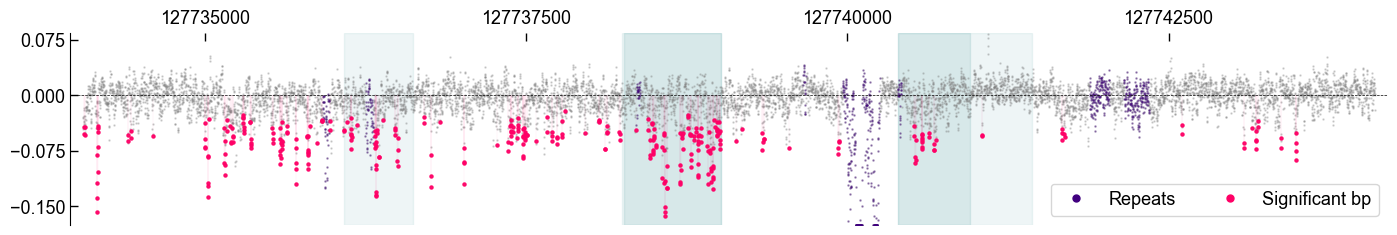

0 values occur more than once.
Cas9-LMOI_D20_vs_Cas9-HMOI_D0|neg|lfc 20
Cas9-LMOI_D8_vs_Cas9-HMOI_D0|neg|lfc 8
Cas9_SpRY_L_MOI_D_20_vs_Cas9-HMOI_D0|neg|lfc 20
Cas9_SpRY_L_MOI_D_8_vs_Cas9-HMOI_D0|neg|lfc 8
   Cas9-LMOI_D20_vs_Cas9-HMOI_D0|neg|lfc  \
0                              -0.021199   
1                              -0.023962   
2                              -0.028680   
3                              -0.026367   
4                              -0.023547   
5                              -0.034916   
6                              -0.024964   

   Cas9-LMOI_D8_vs_Cas9-HMOI_D0|neg|lfc  \
0                             -0.039016   
1                             -0.044454   
2                             -0.047032   
3                             -0.047514   
4                             -0.032453   
5                             -0.054218   
6                             -0.040031   

   Cas9_SpRY_L_MOI_D_20_vs_Cas9-HMOI_D0|neg|lfc  \
0                                      0.02363

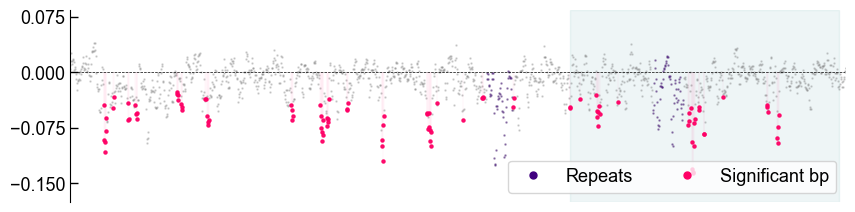

In [28]:
gene = "MYC"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
merge_method_replicate = "mean"
scatter_LFC_nucleotide_merge(
	gene, 
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	merge_method_replicate, per_time_unit=True, title="whole")
scatter_LFC_nucleotide_merge(
	gene, 
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	merge_method_replicate, per_time_unit=True, title="5end", plot_start=127736084-1000, plot_end=127736635, figsize=(10, 2.5))

------  
# Window

In [11]:
def scatter_LFC_nucleotide_window(df, ax, edited_pos_chr_col, ymin, ymax, gene_start, gene_end, window_size, xticks = False):

	# sliding window
	df = df.sort_values(edited_pos_chr_col).reset_index(drop=True)
	# print(df.head(5))
	df["smoothed_lfc"] = (df["neg|lfc"].rolling(window=window_size, center=True, min_periods=1).mean())
	df["center_pos"] = df[edited_pos_chr_col]
	df["neg|lfc"] = df["smoothed_lfc"].clip(lower=ymin, upper=ymax)
	# print(df.head(5))

	# # non-overlapping windows
	# df['window_start'] = ((df[edited_pos_chr_col] - 1) // window_size) * window_size + 1  # match each row to window_size-bp window start (1-based)
	# group_sizes = df.groupby('window_start').size()
	# num_exactly_window_size = (group_sizes == window_size).sum()
	# num_not_window_size = (group_sizes != window_size).sum()
	# print(num_exactly_window_size, num_not_window_size)
	# df = df.groupby('window_start').agg({
	# 	'neg|lfc': 'mean'
	# }).reset_index()
	# df['center_pos'] = df['window_start'] + (window_size // 2)

	# # add exon shades
	# exons = [(127736084, 127736623), (127738248, 127739019), (127740396, 127741434)]
	# for x1, x2 in exons:
	# 	# ax.axvline(x=x1, color='#107F80', linestyle='--')
	# 	# ax.axvline(x=x2, color='#107F80', linestyle='--')
	# 	ax.axvspan(x1, x2, color='#107F80', alpha=0.07)
	# cdss = [(127738263, 127739019), (127740396, 127740958)]
	# for x1, x2 in cdss:
	# 	ax.axvspan(x1, x2, color='#107F80', alpha=0.1)

	ax.plot(df['center_pos'], df['neg|lfc'], linestyle='-', linewidth=1, color="grey", alpha=0)

	ax.axhline(0, linestyle="--", color='black', linewidth=0.5)
	ax.fill_between(df['center_pos'], df['neg|lfc'], 0, where=(df['neg|lfc'] >= 0), interpolate=True, color="#66CCFE", alpha=0.55)
	ax.fill_between(df['center_pos'], df['neg|lfc'], 0, where=(df['neg|lfc'] < 0), interpolate=True, color="#FF0066", alpha=0.5)
	# add exon & repeat shades (white)
	cdss = [(127738263, 127739019), (127740396, 127740808)]	# show the last 100 bp, -150 bp npw
	repeats = [(127735917, 127735968), (127736250, 127736311), (127738359, 127738386), 
			(127739657, 127739675), (127739964, 127740251), (127740393, 127740421),
			(127741885, 127742040), (127742153, 127742348)]
	for x1, x2 in cdss:
		ax.axvspan(x1-50, x2+50, color='white', alpha=0.95)
	for x1, x2 in repeats:
		ax.axvspan(x1-50, x2+50, color='white', alpha=0.95)

	ax.set_ylabel('base pair phenotype score', fontsize=16)
	ax.set_xlim(gene_start, gene_end)
	ax.set_ylim(ymin, ymax)
	ax.set_xlabel('')
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)
	ax.legend(frameon=False)
	ax.set_yticks([-0.04, -0.02, 0.0])
	ax.ticklabel_format(style='plain', axis='y')
	if xticks == False:
		ax.set_xticks([])
		ax.set_xticklabels([])
	else:
		ax.set_xticks([127735000, 127737500, 127740000, 127742500])
		ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable offset and scientific notation
		ax.ticklabel_format(style='plain', axis='x')
		ax.tick_params(axis='both', which='both', direction='in', length=6, width=1, labelsize=13)
		ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

In [ ]:
def scatter_LFC_nucleotide_merge_window(
		gene, 
		date,
		test_name,
		nc_test_name,
		merge_method_nucleotide, 
		win_size,
		baseline,
		treatments,
		day_numbers,
		merge_method_replicate, 
		window_size,
		per_time_unit=True, title=None, plot_start=None, plot_end=None):
	
	# preprocess
	df_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{test_name}/{merge_method_nucleotide}/myc_repeats/{win_size}/MYC_U1.gene_summary.txt"
	df = pd.read_csv(df_path, sep="\t")
	pattern = f"^({'|'.join(map(re.escape, id_prefix_list))})([0-9]*\.?[0-9]+)"
	df = df[df['id'].str.match(pattern)]
	edited_pos_chr_col = "nucleotide_pos"
	df[edited_pos_chr_col] = df['id'].str.extract(pattern)[1].astype(int)

	# check
	count = df[edited_pos_chr_col].value_counts()
	num_duplicates = (count > 1).sum()
	print(f"{num_duplicates} values occur more than once.")

	# merge
	treatment_lfc_columns = [f"{treatment}_vs_{baseline}|neg|lfc" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_columns, day_numbers):
			df[col] = df[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df["neg|lfc"] = df[treatment_lfc_columns].mean(axis=1)

	# add repeats
	rmsk_path = "/media/dna/fy2306/genomes/hg38/RepeatMasker/rmsk.txt"
	rmsk_colnames = ["bin", "swScore", "milliDiv", "milliDel", "milliIns", "genoName", "genoStart", "genoEnd", "genoLeft", "strand", "repName", "repClass", "repFamily", "repStart", "repEnd", "repLeft", "id"]
	rmsk = pd.read_csv(rmsk_path, sep="\t", header=None, names=rmsk_colnames)
	rmsk = rmsk[rmsk['genoName'] == "chr8"]
	# rmsk: 0-based
	rmsk_ranges = pr.PyRanges(rmsk.rename(columns={
	'genoName': 'Chromosome',
	'genoStart': 'Start',
	'genoEnd': 'End'
	}))

	# base_pos: 1-based
	df['Start'] = df[edited_pos_chr_col] - 1
	df['End'] = df['Start'] + 1
	df['Chromosome'] = 'chr8'

	# save as bedgraph for viz
	df_bedgraph = df[['Chromosome', 'Start', 'End', 'neg|lfc']].copy()
	df_bedgraph.to_csv('/media/scratch/fy2306/projects/base_editing/results/20250416/nucleotide_negLFC_timeunit_mean_4.bedGraph', sep='\t', header=False, index=False)

	df["orig_index"] = df.index
	df_ranges = pr.PyRanges(df[['Chromosome', 'Start', 'End', 'orig_index']])

	overlap = df_ranges.intersect(rmsk_ranges, how="containment")	# in pyranges: “containment” reports intervals where the overlapping is contained within it, gives you the intervals in self be completely within the intervals in other
	overlap_indices = overlap.df['orig_index'].unique()

	df["indel_repeats"] = False
	df.loc[overlap_indices, "indel_repeats"] = True

	# process the negative controls
	df_nc = None
	for treatment in treatments:
		df_nc_path = f"/media/scratch/fy2306/projects/base_editing/data/{date}/mageck/{nc_test_name}/MYC_U1.{treatment}_vs_{baseline}.sgrna_summary.txt"
		df_nc_rep = pd.read_csv(df_nc_path, sep="\t", usecols=["sgrna", "Gene", "LFC"])
		df_nc_rep = df_nc_rep[df_nc_rep["Gene"].isin(["AAVS1", "NT", "Random"])]
		df_nc_rep = df_nc_rep.drop('Gene', axis=1)
		df_nc_rep = df_nc_rep.rename(columns={"LFC": f"LFC_{treatment}"})
		if df_nc is None:
			df_nc = df_nc_rep
		else:
			# Merge on 'sgrna'
			df_nc = pd.merge(df_nc, df_nc_rep, on="sgrna", how="inner")
	print(len(df_nc))

	treatment_lfc_nc_columns = [f"LFC_{treatment}" for treatment in treatments]

	if per_time_unit:
		for col, day in zip(treatment_lfc_nc_columns, day_numbers):
			df_nc[col] = df_nc[col] / (day + 0) # per time unit.

	if merge_method_replicate == "mean":
		df_nc["per time unit LFC"] = df_nc[treatment_lfc_nc_columns].mean(axis=1)

	# remove mismatches
	df_nc = df_nc[~(df_nc["sgrna"].isin(mapped_ctrl_list))]
	df_nc = df_nc[['sgrna', 'per time unit LFC']]

	# random group of df_nc
	n_repeats = 1000
	all_results = []

	for seed in range(n_repeats):
		df_nc_result = group_and_aggregate(df_nc, group_size=2*int(win_size), random_state=seed)
		all_results.append(df_nc_result)

	df_nc_combined = pd.concat(all_results, ignore_index=True)
	nc_combined_median_value = df_nc_combined["per time unit LFC"].median()
	print(nc_combined_median_value)

	df["neg|lfc"] = df["neg|lfc"] - nc_combined_median_value

	if gene == "MYC":
		chromosome = "8"
		gene_start = int(df[edited_pos_chr_col].min()) - 100
		gene_end = int(df[edited_pos_chr_col].max()) + 100
		print(f"Actual gene boundary: {df[edited_pos_chr_col].min()}  {df[edited_pos_chr_col].max()}")
		strand = "+"
		# Current Ensembl/Refseq annotations do not seem to reach an agreement on c-Myc.  
		# ENST00000621592.8
		gene_annotation_ENST00000621592 = {
			'gene': {'start': 127736231, 'end': 127742951, 'strand': '+'},
			'exon': [{'start': 127736231, 'end': 127736623}, {'start': 127738248, 'end': 127739019}, {'start': 127740396, 'end': 127742951}],
			'cds': [{'start': 127736594, 'end': 127736623}, {'start': 127738248, 'end': 127739019}, {'start': 127740396, 'end': 127740958}]
			}
		# ENST00000377970.6
		gene_annotation_ENST00000377970 = {
			'gene': {'start': 127736084, 'end': 127741434, 'strand': '+'},
			'exon': [{'start': 127736084, 'end': 127736623}, {'start': 127738248, 'end': 127739019}, {'start': 127740396, 'end': 127741434}],
			'cds': [{'start': 127738263, 'end': 127739019}, {'start': 127740396, 'end': 127740958}]
			}
		# NM_002467.6: same as ENST00000621592.8
		# NM_001354870.1
		gene_annotation_NM_001354870 = {
			'gene': {'start': 127735434, 'end': 127742951, 'strand': '+'},
			'exon': [{'start': 127735434, 'end': 127736623}, {'start': 127738251, 'end': 127739019}, {'start': 127740396, 'end': 127742951}],
			'cds': [{'start': 127736594, 'end': 127736623}, {'start': 127738251, 'end': 127739019}, {'start': 127740396, 'end': 127740958}]
			}


	# plot
	fig, (ax_smooth) = plt.subplots(1, 1, sharex=True, figsize=(16, 4), gridspec_kw={'height_ratios': [1], 'hspace': 0.05})

	# ax_smooth: 
	scatter_LFC_nucleotide_window(
		df = df,
		ax = ax_smooth, 
		edited_pos_chr_col = edited_pos_chr_col, 
		ymin = -0.04, 
		ymax = 0.02, 
		gene_start = gene_start,
		gene_end = gene_end,
		window_size = window_size,
		xticks = True
	)
	if plot_start is not None and plot_end is not None:
		ax_smooth.set_xlim(plot_start, plot_end)

	# # ax_ENST00000377970: myc2 ENST00000377970 anno
	# gene_anno(
	# 	ax_gene = ax_ENST00000377970,
	# 	gene_annotation = gene_annotation_ENST00000377970,
	# 	gene_start = gene_start,
	# 	gene_end = gene_end,
	# 	ylabel = "ENST00000377970.6"
	# )

	# fig.suptitle(f"Merge all 4 replicates per nucleotide (nucleotide window:{win_size})\n ", fontsize=20, fontweight='bold')
	
	# fig.text(0.5, 0.90, f"{merge_method_nucleotide} per time unit, 4 replicates merged by {merge_method_replicate} \n Non-overlapping window: {str(window_size)}", fontsize=18, ha='center', color='gray')
	ax_smooth.set_ylabel(None)
	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/screening/basepair_lfc_along_sequence.window{title}.pdf", 
			bbox_inches="tight",
			dpi=300,              
			transparent=True,
			format='pdf')
	plt.show()


0 values occur more than once.
565


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


-0.0028773212890625005
Actual gene boundary: 127734053  127744107


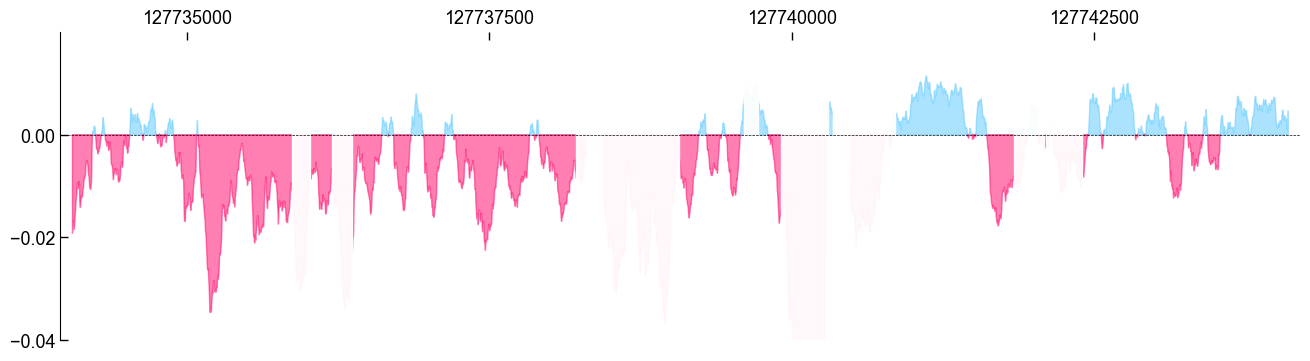

0 values occur more than once.
565


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


-0.0028773212890625005
Actual gene boundary: 127734053  127744107


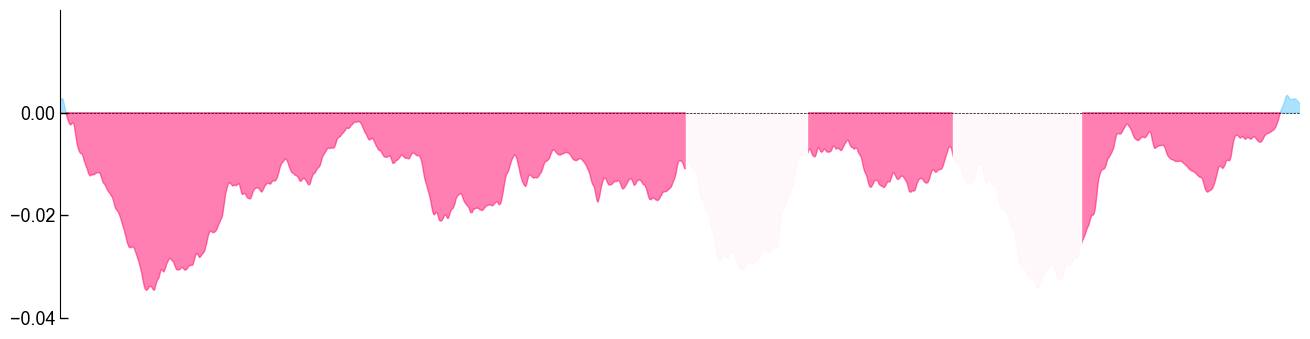

In [18]:
gene = "MYC"
date = "20250416"
test_name = "test-1-standard-nucleotide/test"
nc_test_name = "test-1-standard/test"
merge_method_nucleotide = "mean"
win_size = "4"
baseline = "Cas9-HMOI_D0"
treatments = ["Cas9-LMOI_D20", "Cas9-LMOI_D8", "Cas9_SpRY_L_MOI_D_20", "Cas9_SpRY_L_MOI_D_8"]
day_numbers = [20, 8, 20, 8]
merge_method_replicate = "mean"
window_size = 101
scatter_LFC_nucleotide_merge_window(
	gene, 
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	merge_method_replicate, 
	window_size,
	per_time_unit=True, title="")
scatter_LFC_nucleotide_merge_window(
	gene, 
	date,
	test_name,
	nc_test_name,
	merge_method_nucleotide, 
	win_size,
	baseline,
	treatments,
	day_numbers,
	merge_method_replicate, 
	window_size,
	per_time_unit=True, title="5end", plot_start=127736084-1000, plot_end=127736635)